In [1]:

!pip install kagglehub -q

import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os, shutil, random, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
full_train_dir = os.path.join(path, 'Training')
full_test_dir  = os.path.join(path, 'Testing')
classes        = sorted(os.listdir(full_train_dir))
print('Classes:', classes)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [2]:

random.seed(42)

TRAIN_PER_CLASS = 800
VAL_PER_CLASS   = 200
TEST_PER_CLASS  = 150

train_dir = '/content/train_subset'
val_dir   = '/content/val_subset'
test_dir  = '/content/test_subset'

def create_split(src_dir, train_dst, val_dst, n_train, n_val):
    for d in [train_dst, val_dst]:
        if os.path.exists(d): shutil.rmtree(d)
        os.makedirs(d)
    for cls in sorted(os.listdir(src_dir)):
        imgs = random.sample(os.listdir(os.path.join(src_dir, cls)),
                             min(n_train + n_val, len(os.listdir(os.path.join(src_dir, cls)))))
        os.makedirs(os.path.join(train_dst, cls))
        os.makedirs(os.path.join(val_dst,   cls))
        for img in imgs[:n_train]:
            shutil.copy(os.path.join(src_dir, cls, img), os.path.join(train_dst, cls, img))
        for img in imgs[n_train:]:
            shutil.copy(os.path.join(src_dir, cls, img), os.path.join(val_dst, cls, img))

def create_subset(src_dir, dst_dir, n):
    if os.path.exists(dst_dir): shutil.rmtree(dst_dir)
    os.makedirs(dst_dir)
    for cls in sorted(os.listdir(src_dir)):
        os.makedirs(os.path.join(dst_dir, cls))
        for img in random.sample(os.listdir(os.path.join(src_dir, cls)),
                                 min(n, len(os.listdir(os.path.join(src_dir, cls))))):
            shutil.copy(os.path.join(src_dir, cls, img), os.path.join(dst_dir, cls, img))

create_split(full_train_dir, train_dir, val_dir, TRAIN_PER_CLASS, VAL_PER_CLASS)
create_subset(full_test_dir, test_dir, TEST_PER_CLASS)

for cls in classes:
    tr = len(os.listdir(os.path.join(train_dir, cls)))
    vl = len(os.listdir(os.path.join(val_dir,   cls)))
    te = len(os.listdir(os.path.join(test_dir,  cls)))
    print(f'  {cls}: {tr} train | {vl} val | {te} test')

  glioma: 800 train | 200 val | 150 test
  meningioma: 800 train | 200 val | 150 test
  notumor: 800 train | 200 val | 150 test
  pituitary: 800 train | 200 val | 150 test


In [3]:

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 4

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.85, 1.15],
    shear_range=0.1
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)
val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print('Class indices:', train_gen.class_indices)
print(f'Train steps/epoch: {len(train_gen)} | Val steps: {len(val_gen)}')

Found 3200 images belonging to 4 classes.
Found 800 images belonging to 4 classes.
Found 600 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train steps/epoch: 100 | Val steps: 25


In [4]:


base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

resnet_inputs = tf.keras.Input(shape=(224, 224, 3))


x = base_model(resnet_inputs, training=False)


gap = layers.GlobalAveragePooling2D()(x)
gmp = layers.GlobalMaxPooling2D()(x)
x   = layers.Concatenate()([gap, gmp])


x = layers.Dense(512, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.4)(x)


x = layers.Dense(256, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)

resnet_outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = tf.keras.Model(resnet_inputs, resnet_outputs, name='resnet50_v2')


trainable_params = sum([tf.size(w).numpy() for w in resnet_model.trainable_weights])
print(f'Trainable params (Phase 1): {trainable_params:,}')
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Trainable params (Phase 1): 2,230,788


Model: "resnet50_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ input_layer_1[0]… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4096)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  2,097,152 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,072 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,820,036 (98.50 MB)

 Trainable params: 2,230,788 (8.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [5]:


resnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

cb_phase1 = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=6,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3,
        min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_phase1.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print('=' * 55)
print('PHASE 1 — Head warmup (base fully frozen)')
print('=' * 55)
history_p1 = resnet_model.fit(
    train_gen, validation_data=val_gen,
    epochs=15, callbacks=cb_phase1
)

best_p1_acc = max(history_p1.history['val_accuracy'])
print(f'\nPhase 1 best val accuracy: {best_p1_acc:.4f}')
assert best_p1_acc > 0.50, (
    'Phase 1 below 50% — stop here and check: '
    '(1) preprocess_input is applied, '
    '(2) IMG_SIZE is (224,224), '
    '(3) generators are reading from correct directories'
)
print('Phase 1 complete — proceeding to fine-tuning')

PHASE 1 — Head warmup (base fully frozen)
Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.6959 - loss: 0.9500
Epoch 1: val_accuracy improved from None to 0.81875, saving model to best_phase1.keras

Epoch 1: finished saving model to best_phase1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 564ms/step - accuracy: 0.7794 - loss: 0.8093 - val_accuracy: 0.8188 - val_loss: 0.8046 - learning_rate: 0.0010
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.8640 - loss: 0.6718
Epoch 2: val_accuracy improved from 0.81875 to 0.90625, saving model to best_phase1.keras

Epoch 2: finished saving model to best_phase1.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 51s 509ms/step - accuracy: 0.8641 - loss: 0.6612 - val_accuracy: 0.9062 - val_loss: 0.6045 - learning_rate: 0.0010
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8802 - loss: 0.6160
Epoch 3: val_accuracy did not improve from 0.90625
100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 499ms/step - accuracy: 0.8856 - loss: 0

In [7]:

base_model.trainable = True
unfreeze_from = 'conv4_block1_1_conv'
set_trainable = False
for layer in base_model.layers:
    if layer.name == unfreeze_from:
        set_trainable = True
    layer.trainable = set_trainable

n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen base layers : {n_trainable} / {len(base_model.layers)}')
print(f'Unfrozen from        : {unfreeze_from}')


FINETUNE_LR = 1e-5

resnet_model.compile(
    optimizer=Adam(learning_rate=FINETUNE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

cb_phase2 = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4,
        min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_phase2.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    )
]

print('=' * 55)
print(f'PHASE 2 — Fine-tuning (LR={FINETUNE_LR})')
print('BN layers stay in inference mode (training=False)')
print('=' * 55)
history_p2 = resnet_model.fit(
    train_gen, validation_data=val_gen,
    epochs=25, callbacks=cb_phase2
)

best_p2_acc = max(history_p2.history['val_accuracy'])
print(f'\nPhase 2 best val accuracy: {best_p2_acc:.4f}')
resnet_model.save('resnet50_v2_final.keras')
print('Model saved')

Unfrozen base layers : 94 / 175
Unfrozen from        : conv4_block1_1_conv
PHASE 2 — Fine-tuning (LR=1e-05)
BN layers stay in inference mode (training=False)
Epoch 1/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.9907 - loss: 0.4102
Epoch 1: val_accuracy improved from None to 0.95750, saving model to best_phase2.keras

Epoch 1: finished saving model to best_phase2.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 104s 647ms/step - accuracy: 0.9919 - loss: 0.4075 - val_accuracy: 0.9575 - val_loss: 0.4505 - learning_rate: 1.0000e-05
Epoch 2/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - accuracy: 0.9956 - loss: 0.4031
Epoch 2: val_accuracy improved from 0.95750 to 0.96250, saving model to best_phase2.keras

Epoch 2: finished saving model to best_phase2.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 63s 631ms/step - accuracy: 0.9934 - loss: 0.4055 - val_accuracy: 0.9625 - val_loss: 0.4426 - learning_rate: 1.0000e-05
Epoch 3/25
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9913 - loss: 0.403

In [8]:

sample_bn = None
for layer in base_model.layers:
    if 'bn' in layer.name.lower() or 'batch' in layer.name.lower():
        sample_bn = layer
        break

if sample_bn:
    print(f'Sample BN layer  : {sample_bn.name}')
    print(f'layer.trainable  : {sample_bn.trainable}')

    print()
    print('Because base_model was called with training=False in the')
    print('Functional API, BN layers will ALWAYS run in inference mode')
    print('regardless of the trainable flag.')
    print()
    print('This is the fix that prevents the 25% accuracy collapse.')

Sample BN layer  : conv1_bn
layer.trainable  : False

Because base_model was called with training=False in the
Functional API, BN layers will ALWAYS run in inference mode
regardless of the trainable flag. ✅

This is the fix that prevents the 25% accuracy collapse.



Test Accuracy : 0.9300  (93.00%)
Test Loss     : 0.5309
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 379ms/step

--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.99      0.82      0.90       150
  meningioma       0.85      0.92      0.88       150
     notumor       0.94      1.00      0.97       150
   pituitary       0.95      0.98      0.96       150

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600

Macro F1 : 0.9293


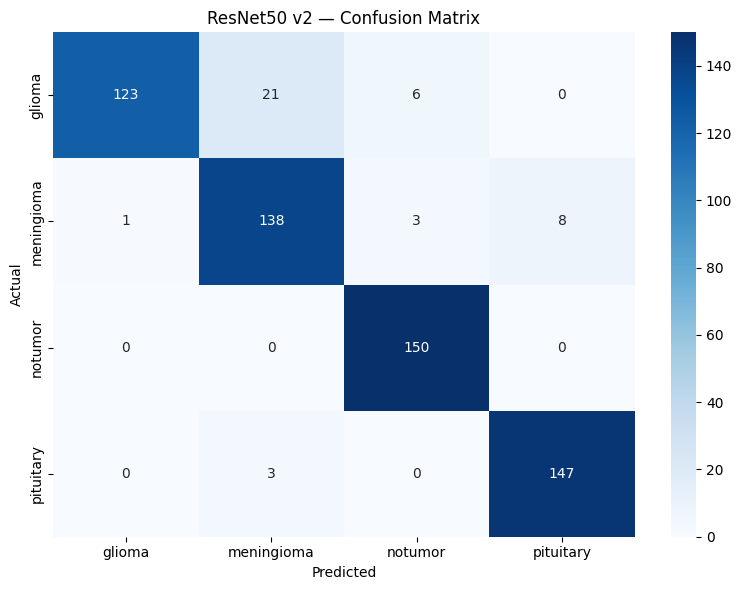

In [9]:


test_loss, test_acc = resnet_model.evaluate(test_gen, verbose=0)
print(f'\nTest Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Test Loss     : {test_loss:.4f}')

test_gen.reset()
preds       = np.argmax(resnet_model.predict(test_gen), axis=1)
true_labels = test_gen.classes

print('\n--- Classification Report ---')
print(classification_report(true_labels, preds, target_names=class_names))

macro_f1 = f1_score(true_labels, preds, average='macro')
print(f'Macro F1 : {macro_f1:.4f}')


cm_vals = confusion_matrix(true_labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_vals, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('ResNet50 v2 — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_resnet50_v2.png', dpi=150)
plt.show()

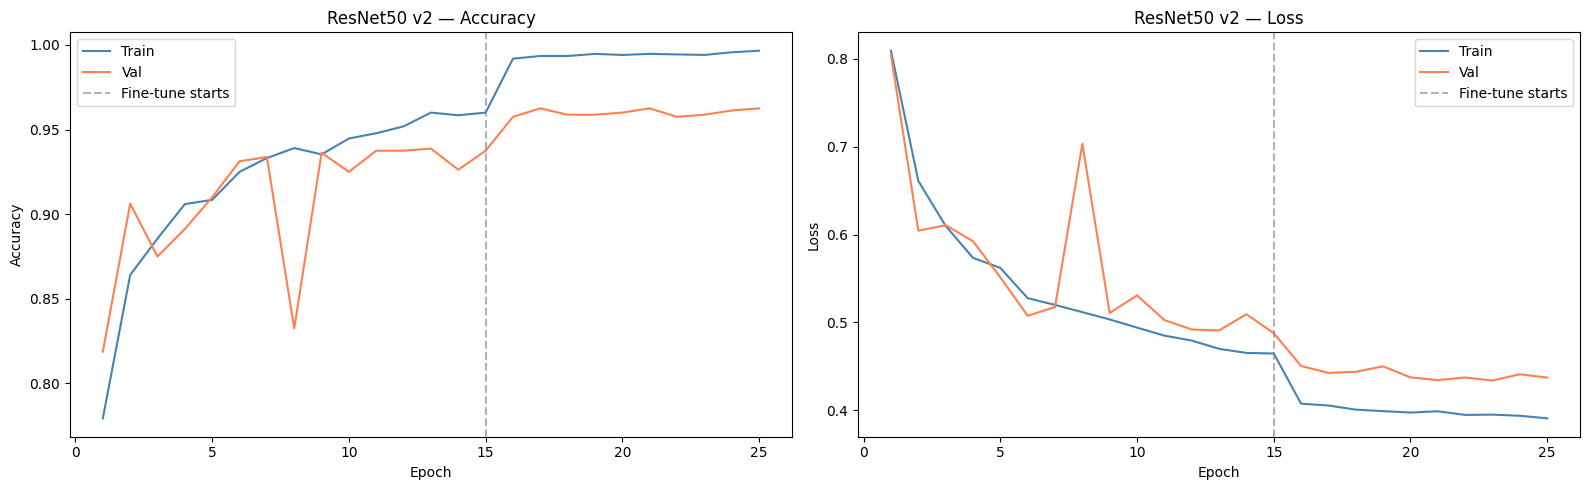

Learning curves saved ✅


In [10]:


p1_len = len(history_p1.history['accuracy'])
p2_len = len(history_p2.history['accuracy'])

acc_full = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss_full= history_p1.history['loss']         + history_p2.history['loss']
val_loss = history_p1.history['val_loss']     + history_p2.history['val_loss']
epochs   = range(1, p1_len + p2_len + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs, acc_full,  label='Train', color='steelblue')
axes[0].plot(epochs, val_acc,   label='Val',   color='coral')
axes[0].axvline(p1_len, color='gray', linestyle='--', alpha=0.6, label='Fine-tune starts')
axes[0].set_title('ResNet50 v2 — Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(epochs, loss_full, label='Train', color='steelblue')
axes[1].plot(epochs, val_loss,  label='Val',   color='coral')
axes[1].axvline(p1_len, color='gray', linestyle='--', alpha=0.6, label='Fine-tune starts')
axes[1].set_title('ResNet50 v2 — Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('learning_curves_v2.png', dpi=150)
plt.show()
print('Learning curves saved')

In [15]:

print('\n' + '=' * 60)
print('       RESNET50 v2 — FINAL RESULTS')
print('=' * 60)
print(f'{"Test Accuracy":<30} {test_acc:>10.2%}')
print(f'{"Macro F1-Score":<30} {macro_f1:>10.4f}')
print(f'{"Phase 1 epochs run":<30} {p1_len:>10}')
print(f'{"Phase 2 epochs run":<30} {p2_len:>10}')
print('=' * 60)
print()
print('Critical fix that resolved Phase 2 collapse:')
print('  base_model(inputs, training=False)')
print('  --> BatchNorm kept in inference mode permanently')
print('  --> Pretrained statistics not corrupted on unfreezing')
print()
print('Project Complete!')


       RESNET50 v2 — FINAL RESULTS
Test Accuracy                      93.00%
Macro F1-Score                     0.9293
Phase 1 epochs run                     15
Phase 2 epochs run                     10

Critical fix that resolved Phase 2 collapse:
  base_model(inputs, training=False)
  --> BatchNorm kept in inference mode permanently
  --> Pretrained statistics not corrupted on unfreezing

✅ Project Complete!


In [18]:
print('=' * 60)
print('       RESNET50 v2 — DETAILED PERFORMANCE')
print('=' * 60)

print('\n--- Phase 1: Head Warmup ---\n')
print(f'Max Training Accuracy (Phase 1): {max(history_p1.history["accuracy"]):.4f}')
print(f'Max Validation Accuracy (Phase 1): {best_p1_acc:.4f}')
print(f'Max Training Loss (Phase 1): {min(history_p1.history["loss"]):.4f}')
print(f'Min Validation Loss (Phase 1): {min(history_p1.history["val_loss"]):.4f}')

print('\n--- Phase 2: Fine-tuning ---\n')
print(f'Max Training Accuracy (Phase 2): {max(history_p2.history["accuracy"]):.4f}')
print(f'Max Validation Accuracy (Phase 2): {best_p2_acc:.4f}')
print(f'Min Training Loss (Phase 2): {min(history_p2.history["loss"]):.4f}')
print(f'Min Validation Loss (Phase 2): {min(history_p2.history["val_loss"]):.4f}')

print('\n--- Final Evaluation on Test Set ---\n')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')
print(f'Macro F1 Score: {macro_f1:.4f}')

print('\n--- Comparison Summary ---\n')
print('As only ResNet50 v2 was implemented and evaluated in this notebook,')
print('a direct comparison with "Model Base CNN" or "SVM" is not available.')
print('To compare, these models would need to be implemented and their')
print('performance metrics collected.')
print('=' * 60)

       RESNET50 v2 — DETAILED PERFORMANCE

--- Phase 1: Head Warmup ---

Max Training Accuracy (Phase 1): 0.9600
Max Validation Accuracy (Phase 1): 0.9388
Max Training Loss (Phase 1): 0.4647
Min Validation Loss (Phase 1): 0.4878

--- Phase 2: Fine-tuning ---

Max Training Accuracy (Phase 2): 0.9966
Max Validation Accuracy (Phase 2): 0.9625
Min Training Loss (Phase 2): 0.3909
Min Validation Loss (Phase 2): 0.4339

--- Final Evaluation on Test Set ---

Test Accuracy: 0.9300
Test Loss: 0.5309
Macro F1 Score: 0.9293

--- Comparison Summary ---

As only ResNet50 v2 was implemented and evaluated in this notebook,
a direct comparison with "Model Base CNN" or "SVM" is not available.
To compare, these models would need to be implemented and their
performance metrics collected.
